# Emission Spectrum Basics

Emission spectroscopy measures the planet's thermal radiation relative to the star as a function of wavelength. Unlike transmission, emission is sensitive to the vertical temperature structure of the atmosphere.

This example uses molecular absorption only (no CIA or Rayleigh scattering) with an isothermal temperature profile.

## External Data Note

This notebook reuses opacity data obtained from external providers in notebook 1. TauREx provides the analysis software only: these datasets are third-party products, are not owned or warranted by the TauREx team, and responsibility for their content remains with the original data providers.

In [1]:
from _shared import build_emission_model

context = build_emission_model(include_cia=False, include_rayleigh=False, download=False)
em = context['em']

print('Emission model contributions:', [c.name for c in em.contribution_list])

Emission model contributions: ['Absorption']


## Running the Forward Model

The `model()` call returns the wavenumber grid, the planet-to-star flux ratio $(F_p/F_s)$, the optical-depth array, and extras. With an isothermal profile, the baseline emission spectrum is nearly blackbody-like.

In [2]:
wngrid, fpfs, tau, _ = em.model()
wlgrid = 10000 / wngrid[::-1]
fpfs = fpfs[::-1]

print(f'Computed {len(wngrid)} spectral points.')
print(f'Temperature profile spans {em.temperatureProfile.min():.1f} K to {em.temperatureProfile.max():.1f} K')

Computed 76744 spectral points.
Temperature profile spans 2000.0 K to 2000.0 K


In [3]:
print(f'Planet/star flux-ratio range: {fpfs.min():.6e} to {fpfs.max():.6e}')
print(f'Wavelength range: {wlgrid.min():.3f} to {wlgrid.max():.3f} um')

Planet/star flux-ratio range: 1.462632e-09 to 4.652038e-03
Wavelength range: 0.300 to 50.002 um


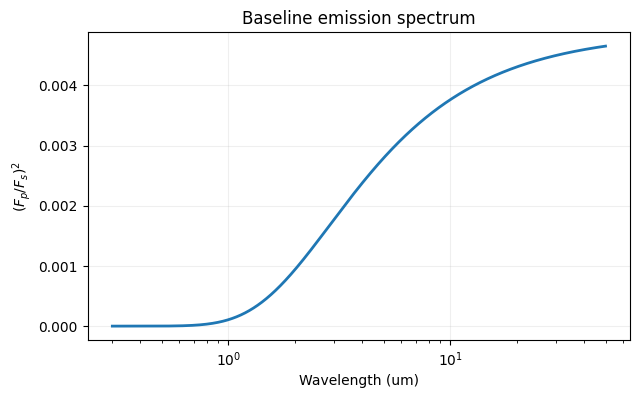

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, fpfs, lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(F_p/F_s)^2$')
plt.title('Baseline emission spectrum')
plt.grid(alpha=0.2)

## Temperature Profile

The temperature profile underlying the emission spectrum can be plotted directly. An isothermal atmosphere produces little vertical contrast, resulting in a smooth spectrum with weak molecular features.

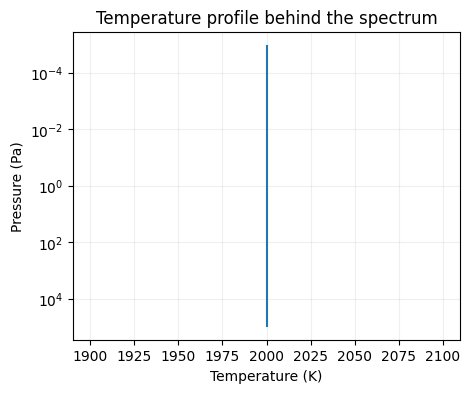

In [5]:
plt.figure(figsize=(5, 4))
plt.plot(em.temperatureProfile, em.pressureProfile)
plt.gca().invert_yaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (Pa)')
plt.title('Temperature profile behind the spectrum')
plt.grid(alpha=0.2)